# **1. Objective:**
A phishing website (spoofed website) is a common deception tactic threat actors utilize to steal real login credentials to legitimate websites. This operation, commonly called credential theft, involves sending victims an email that spoofs a trusted brand, trying to trick them into clicking on a malicious link.

# **Data Collection:**
For this project, we need a bunch of urls of type legitimate (0) and phishing (1).

The collection of phishing urls is rather easy because of the opensource service called PhishTank. This service provide a set of phishing URLs in multiple formats like csv, json etc. that gets updated hourly. To download the data: https://www.phishtank.com/developer_info.php

For the legitimate URLs, I found a source that has a collection of benign, spam, phishing, malware & defacement URLs. The source of the dataset is University of New Brunswick, https://www.unb.ca/cic/datasets/url-2016.html.


#**Phishing URLs**
The phishing URLs are collected from the PhishTank from the link provided. The csv file of phishing URLs is obtained by using wget command. After downlaoding the dataset, it is loaded into a DataFrame.

In [ ]:
%pip install selenium
%pip install pyautogui
%pip install whois
%pip install fastapi
%pip install uvicorn
%pip install nest-asyncio
%pip install pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.9/492.9 kB 37.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.2/171.2 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.

In [ ]:
import pandas as pd
phish_data=pd.read_csv('2.online-valid.csv')
#print(phish_data.shape)

p_url=phish_data.sample(n=100,random_state=12)
p_url=p_url.reset_index(drop=True)
#print(p_url)


In [ ]:
legit_data=pd.read_csv('1.Benign_list_big_final.csv')
legit_data.columns=['URL']
#print(legit_data)

l_url=legit_data.sample(n=100,random_state=12)
l_url=l_url.reset_index(drop=True)
#print(l_url)


Address bar based features

In [ ]:
#1 Domain of URL
from urllib.parse import urlparse
import re
def domain(url):
    global dom
    dom=urlparse(url).netloc
    if (dom[0:4])=='www.':
        dom=dom[4:]
    return dom


In [ ]:
#2 IP Address
from urllib.parse import urlparse
import ipaddress as ip
def ipadd(url):
    try:
        ip.ip_address(urlparse(url).netloc)
        ipa=1
    except:
        ipa=0
    return ipa


In [ ]:
#3 '@' symbol in URL
def atsymbol(url):
    if '@' in url:
        at=1
    else:
        at=0
    return at


In [ ]:
#4 Length of URL
def length(url):
    if (len(url)<54):
        length=0
    else:
        length=1
    return length


In [ ]:
#5 Depth of URL
import re
def depth(url):
    d=re.findall("//.*[.][a-z]*[0-9]*/?.*",url)
    try:
        d=d[0][2:]
    except IndexError:
        return 6
    else:
        d=re.split('/',d)
        d=len(d)-1
        return d

In [ ]:
#6 Redirection
def redirection(url):
    r=url.rfind('//')
    if (r>6):
      if(r>7):
        return 1
      else:
        return 0
    else:
        return 0

In [ ]:
#7 http/https in Domain
def http(url):
    dom=urlparse(url).netloc
    if ('http' or 'https') in dom:
        return 1
    else:
        return 0


In [ ]:
#8 URL Shortening services ("Tiny URL")
def tinyurl(url):
    shortening_services = "bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|"\
                          "yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|"\
                          "short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|"\
                          "doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|db\.tt|"\
                          "qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|q\.gs|is\.gd|"\
                          "po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|x\.co|"\
                          "prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|"\
                          "tr\.im|link\.zip\.net"
    match=re.search(shortening_services,url)
    if match:
        return 1
    else:
        return 0


In [ ]:
#9 Prefix or Suffix '-' in domain
def dash(url):
    dom=urlparse(url).netloc
    if '-' in dom:
        return 1
    else:
        return 0


Domain based features

In [ ]:
#1 DNS record
import whois
from urllib.parse import urlparse
global domain_name

def dnsrecord(url):
    global dns
    dns=0
    try:
        domain_name = whois.whois(urlparse(url).netloc)
    except:
        dns=1
    return dns


In [ ]:
#2 Web Traffic

from bs4 import BeautifulSoup
import requests
import time
import selenium
from selenium import webdriver
from selenium.webdriver.common.by import By
#import pyautogui
import pyperclip

def web_traffic():
  return 1
  '''if dns==1:
    return 1
    count=0
    if count==0:
        driver=webdriver.Edge()
    count=count+1
    #driver=webdriver.Edge()
    driver.get('https://www.blexb.com')
    search_input=driver.find_element(By.ID,'input')
    search_input.send_keys(domain_name)
    time.sleep(1)
    search_input.submit()
    pyautogui.click(x=500,y=90,button='left')
    pyautogui.hotkey('ctrl','c')
    time.sleep(1)
    url=pyperclip.paste()
    try:
        response=requests.get(url)
        web_page=response.text
        soup=BeautifulSoup(web_page,"html.parser")
        soup=str(soup)
        #print(soup)
        rank=re.findall('>[0-9]+[,]?.*[0-9]*<',soup)
        rank=re.findall('\d',rank[0][1:-1])
        #print(rank)
    except IndexError:
        return 1
    except:
        return 1

    rsum=''
    for i in range(0,len(rank)):
        rsum=rsum+rank[i]
    rsum=int(rsum)
    #print(rsum)

    if rsum<100000:
        return 0
    else:
        return 1'''


In [ ]:
#3 Age of Domain
import datetime
def age(domain_name):
  if(dns==1):
    return 1
  creation_date = domain_name.creation_date
  expiration_date = domain_name.expiration_date
  if (isinstance(creation_date,str) or isinstance(expiration_date,str)):
    try:
      creation_date = datetime.strptime(creation_date,'%Y-%m-%d')
      expiration_date = datetime.strptime(expiration_date,"%Y-%m-%d")
    except:
      return 1
  if ((expiration_date is None) or (creation_date is None)):
      return 1
  elif ((type(expiration_date) is list) or (type(creation_date) is list)):
      return 1
  else:
    age_domain = abs((expiration_date - creation_date).days)
    if ((age_domain/30)>12):
      age_d = 0
    else:
      age_d = 1
  return age_d


In [ ]:
#4 End Period of Domain
def endperiod(domain_name):
  if dns==1:
    return 1
  expiration_date = domain_name.expiration_date
  if isinstance(expiration_date,str):
    try:
      expiration_date = datetime.strptime(expiration_date,"%Y-%m-%d")
    except:
      return 1
  if (expiration_date is None):
      return 1
  elif (type(expiration_date) is list):
      return 1
  else:
    today = datetime.now()
    end = abs((expiration_date - today).days)
    if ((end/30)<=6):
      end = 0
    else:
      end = 1
  return end

HTML and JavaScript based features

In [ ]:
#1 Iframe Redirection
import requests
import re
def iframe(url):
    try:
        req=requests.get(url)
    except:
        req=""
    if req=="":
        return 1
    else:
        a=re.findall('[<iframe>|<frameBorder>]|border: none|border:none|frameBorder="0"',req.text)
        if a:
            return 1
        else:
            return 0


In [ ]:
#2 Status Bar Customization
def statusbar(url):
    try:
        req=requests.get(url)
    except:
        req=""
    if req=="":
        return 1
    else:
        a=re.findall('onMouseOver="window.status=|<script>.+onmouseover.+</script>',req.text)
        if a:
            return 1
        else:
            return 0



In [ ]:
#3 Disabling Right Click
def rightclick(url):
    try:
        req=requests.get(url)
    except:
        req=""
    if req=="":
        return 1
    else:
        a=re.findall("event.button ?== ?2",req.text)
        if a:
            return 1
        else:
            return 0


In [ ]:
#4 Website Forwarding
def forward(url):
    try:
        req=requests.get(url)
    except:
        req=""
    if req=="":
        return 1
    else:
        if len(req.history)<=2:
            return 0
        else:
            return 1


Entering Values in Dataset

In [ ]:
def featureExtract(url,label):
    features=[]
    #Address bar based features
    features.append(domain(url))
    features.append(ipadd(url))
    features.append(atsymbol(url))
    features.append(length(url))
    features.append(depth(url))
    features.append(redirection(url))
    features.append(http(url))
    features.append(tinyurl(url))
    features.append(dash(url))

    #Domain based features
    features.append(dnsrecord(url))
    features.append(web_traffic())
    features.append(age(url))
    features.append(endperiod(url))

    #HTML and JavaScript based features
    features.append(iframe(url))
    features.append(statusbar(url))
    features.append(rightclick(url))
    features.append(forward(url))
    features.append(label)
    return list(features)


In [ ]:
# Legitimate
legitimate=[]
label=0

for i in range(0,100):
    a=l_url['URL'][i]
    legitimate.append(featureExtract(a,label))
#print(legitimate)
#converting list to dataframe
names=['Domain','IP Address','@ Symbol','Length of URL',
       'Depth of URL','Redirect','https/http','Tiny URL',
       'Prefix/Suffix','DNS Record','Age of Domain',
       'End Period','IFrame','Mouse_Over','Right_Click','Web_Forward',
       'Label']

legit=pd.DataFrame(legitimate,columns=names)

#Storing this into CSV file
legit.to_csv('LEGIT.csv',index=False)



In [ ]:
# Phishing
phishing=[]
label=1

for i in range(0,100):
    b=p_url['url'][i]
    phishing.append(featureExtract(b,label))

phish=pd.DataFrame(phishing,columns=names)

#Storing this into CSV file
phish.to_csv('PHISH.csv',index=False)


## Final Dataset
dataset=pd.concat([legit,phish]).reset_index(drop=True)



## **Loading the Data:**

The features are extracted and store in the csv file.
The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [ ]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Loading the data
data0 = pd.read_csv('5.urldata.csv')
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## **Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features and perform data preprocessing.

In [ ]:
#Checking the shape of the dataset
data0.shape

(10005, 18)

In [ ]:
#Listing the features of the dataset
data0.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [ ]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10005 non-null  object
 1   Have_IP        10005 non-null  int64 
 2   Have_At        10005 non-null  int64 
 3   URL_Length     10005 non-null  int64 
 4   URL_Depth      10005 non-null  int64 
 5   Redirection    10005 non-null  int64 
 6   https_Domain   10005 non-null  int64 
 7   TinyURL        10005 non-null  int64 
 8   Prefix/Suffix  10005 non-null  int64 
 9   DNS_Record     10005 non-null  int64 
 10  Web_Traffic    10005 non-null  int64 
 11  Domain_Age     10005 non-null  int64 
 12  Domain_End     10005 non-null  int64 
 13  iFrame         10005 non-null  int64 
 14  Mouse_Over     10005 non-null  int64 
 15  Right_Click    10005 non-null  int64 
 16  Web_Forwards   10005 non-null  int64 
 17  Label          10005 non-null  int64 
dtypes: int64(17), object(1)
me

## **Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other using heatmap.

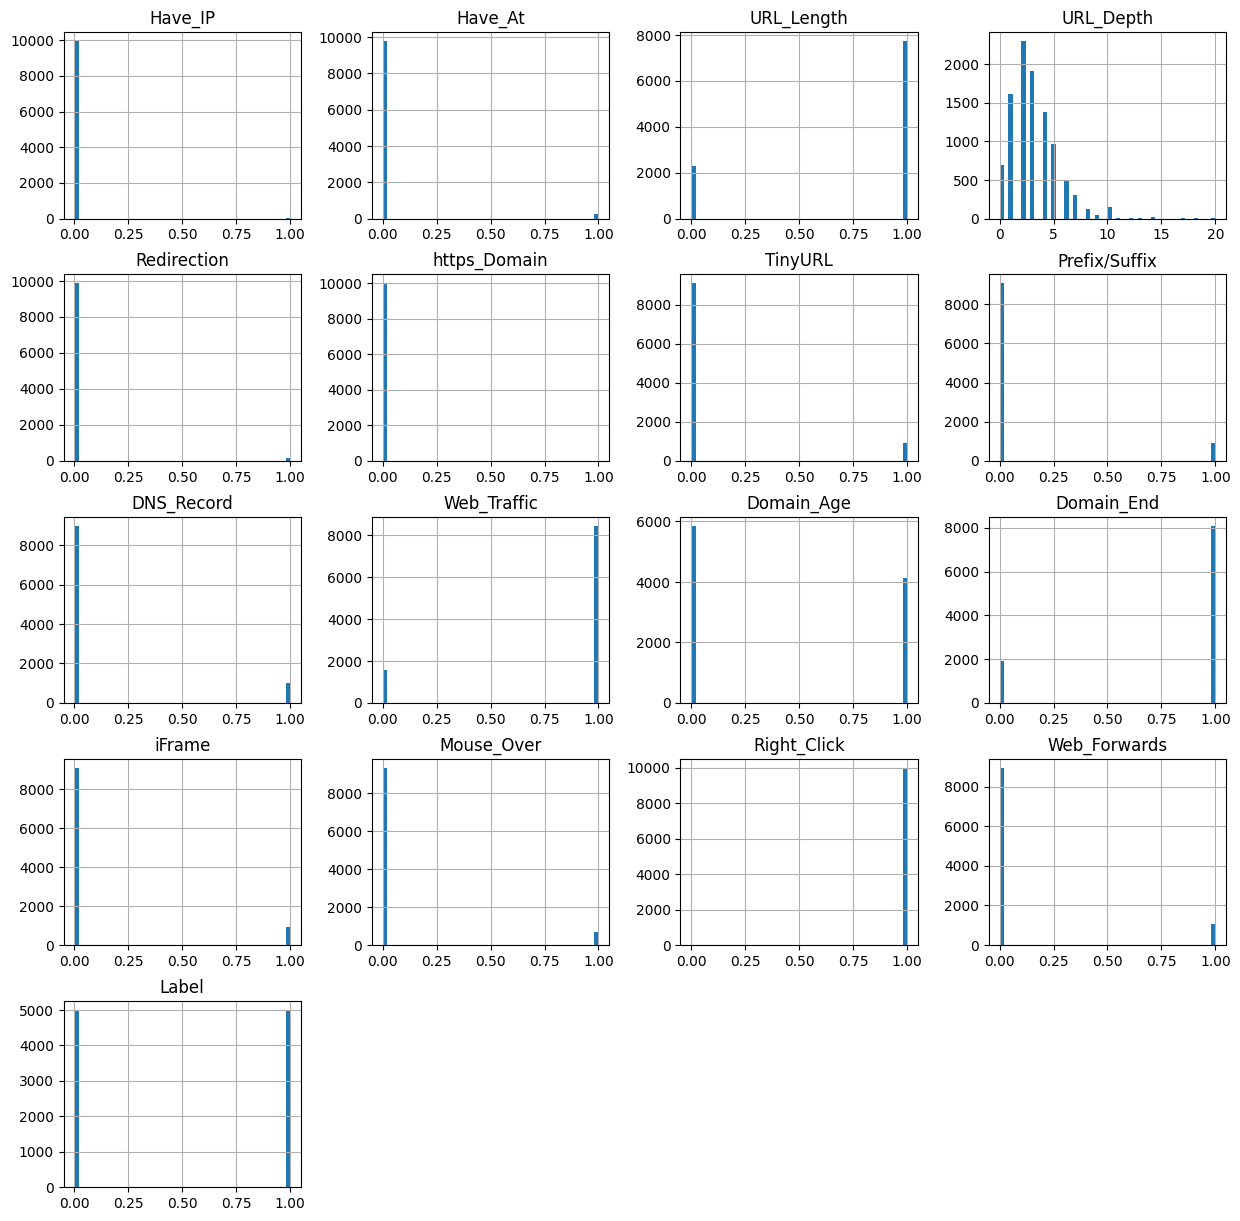

In [ ]:
#Plotting the data distribution
data0.hist(bins = 50,figsize = (15,15))
plt.show()

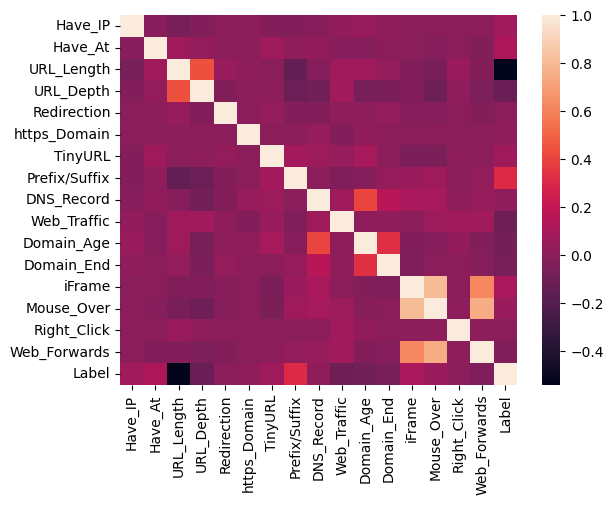

In [ ]:
#Correlation heatmap

#plt.figure(figsize=(15,13))
sns.heatmap(data0.drop(['Domain'], axis = 1).corr())
plt.show()

In [ ]:
data0.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000
mean,0.005497,0.022589,0.773013,3.070465,0.013493,0.000200,0.090255,0.093153,0.100750,0.845277,0.413593,0.809995,0.090955,0.066567,0.998801,0.105247,0.499750
std,0.073943,0.148596,0.418905,2.129206,0.115380,0.014138,0.286561,0.290662,0.301012,0.361658,0.492502,0.392324,0.287559,0.249283,0.034613,0.306887,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#Dropping the Domain column
data = data0.drop(['Domain'], axis = 1).copy()

In [ ]:
#checking the data for null or missing values
data.isnull().sum()

,0
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0
Web_Traffic,0


In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data.

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

In [ ]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
1,0,0,0,2,0,0,0,0,0,1,1,1,0,0,1,0,1
2,0,0,1,4,0,0,1,0,0,1,0,1,0,0,1,0,0
3,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,1
4,0,0,1,2,0,0,0,0,0,1,0,0,0,0,1,0,1


Now the data is thoroughly preprocessed and is ready for training

#**Splitting the data**

In [ ]:
# Sepratating & assigning features and target columns to X & y
y = data['Label']
X = data.drop('Label',axis=1)
X.shape, y.shape

((10005, 16), (10005,))

In [ ]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.15, random_state = 12)
X_train.shape, X_test.shape
print(X_train)

      Have_IP  Have_At  URL_Length  URL_Depth  Redirection  https_Domain  \
3786        0        0           1          3            0             0   
6833        0        0           0          2            0             0   
757         0        0           0          1            0             0   
4954        0        0           1          7            0             0   
4832        0        0           1          2            0             0   
...       ...      ...         ...        ...          ...           ...   
3714        0        0           1          2            0             0   
7409        0        0           0          0            0             0   
3325        0        0           1          6            0             0   
9606        0        0           1          3            0             0   
5787        0        0           1          3            0             0   

      TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  Domain_Age  Domain_End  \
3786  

## **Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression.

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [ ]:
#importing packages
from sklearn.metrics import accuracy_score

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

### **1.Decision Tree Classifier**
 Decision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision. Learning a decision tree means learning the sequence of if/else questions that gets us to the true answer most quickly.

In the machine learning setting, these questions are called tests (not to be confused with the test set, which is the data we use to test to see how generalizable our model is). To build a tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable.

In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

**Evaluating Performance -**

In [ ]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.812
Decision Tree: Accuracy on test Data: 0.820


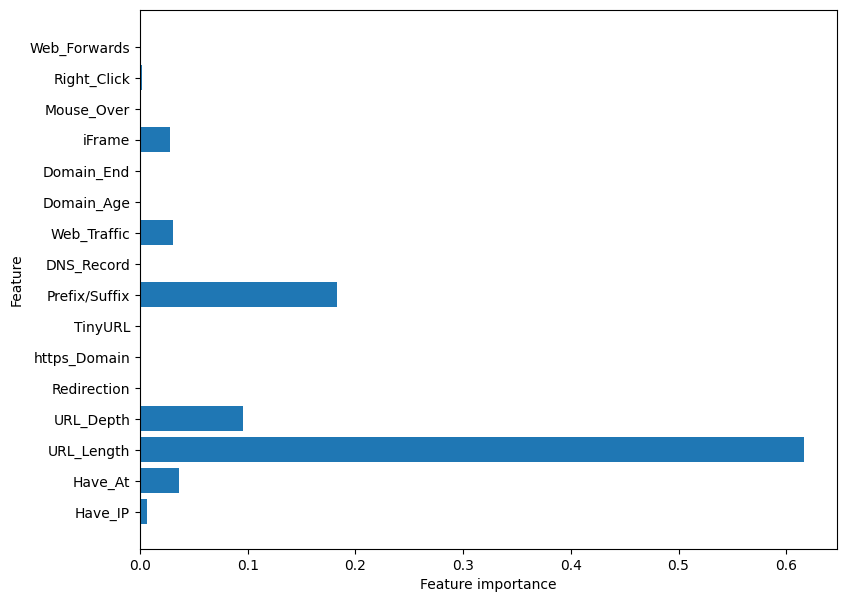

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#Storing the results
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

### **2.Random Forest Classifier**
Random forests for regression and classification are currently among the most widely used machine learning methods.A random forest is essentially a collection of decision trees, where each tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job of predicting, but will likely overfit on part of the data.

If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results. To build a random forest model, you need to decide on the number of trees to build (the n_estimators parameter of RandomForestRegressor or RandomForestClassifier). They are very powerful, often work well without heavy tuning of the parameters, and don’t require scaling of the data.

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

***Evaluating Performance -**

In [ ]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.818
Random forest: Accuracy on test Data: 0.807


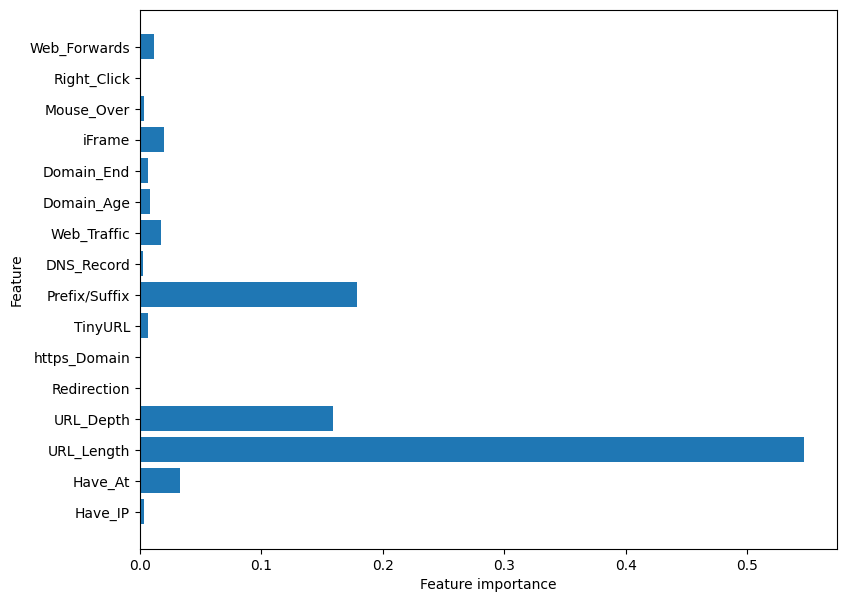

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **3.Multilayer Perceptrons (MLPs): Deep Learning**
Multilayer perceptrons (MLPs) are also known as (vanilla) feed-forward neural networks, or sometimes just neural networks. Multilayer perceptrons can be applied for both classification and regression problems.

MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision.*italicized text*

In [ ]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))

# fit the model
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[100, 100, 100])

In [ ]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

**Evaluating Performance-**

In [ ]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 0.865
Multilayer Perceptrons: Accuracy on test Data: 0.862


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

### **4.XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

In [ ]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Evaluating Performnace-**

In [ ]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.867
XGBoost : Accuracy on test Data: 0.863


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

### **5.Autoencoder Neural Network**
An auto encoder is a neural network that has the same number of input neurons as it does outputs. The hidden layers of the neural network will have fewer neurons than the input/output neurons. Because there are fewer neurons, the auto-encoder must learn to encode the input to the fewer hidden neurons. The predictors (x) and output (y) are exactly the same in an auto encoder.*italicized text*

In [ ]:
#importing required packages
import keras
from keras.layers import Input, Dense
from keras import regularizers
import tensorflow as tf
from keras.models import Model
from sklearn import metrics

In [ ]:
#building autoencoder model

input_dim = X_train.shape[1]
encoding_dim = input_dim

input_layer = Input(shape=(input_dim, ))
encoder = Dense(encoding_dim, activation="relu",
                activity_regularizer=regularizers.l1(10e-4))(input_layer)
encoder = Dense(int(encoding_dim), activation="relu")(encoder)

encoder = Dense(int(encoding_dim-2), activation="relu")(encoder)
code = Dense(int(encoding_dim-4), activation='relu')(encoder)
decoder = Dense(int(encoding_dim-2), activation='relu')(code)

decoder = Dense(int(encoding_dim), activation='relu')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16)]              0         
                                                                 
 dense (Dense)               (None, 16)                272       
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 14)                238       
                                                                 
 dense_5 (Dense)             (None, 16)                240       
                                                                 
 dense_6 (Dense)             (None, 16)                272       
                                                                 
Total params: 1294 (5.05 KB)
Trainable params: 1294 (5.05 KB)

In [ ]:
#compiling the model
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

#Training the model
history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=True, validation_split=0.2)

Epoch 1/10
100/100 [==============================] - 2s 6ms/step - loss: 1.1547 - accuracy: 0.0155 - val_loss: -0.7843 - val_accuracy: 0.0338
Epoch 2/10
100/100 [==============================] - 0s 4ms/step - loss: -1.4178 - accuracy: 0.7094 - val_loss: -1.5183 - val_accuracy: 0.8350
Epoch 3/10
100/100 [==============================] - 0s 3ms/step - loss: -1.5663 - accuracy: 0.8431 - val_loss: -1.5793 - val_accuracy: 0.8350
Epoch 4/10
100/100 [==============================] - 1s 5ms/step - loss: -1.6187 - accuracy: 0.8375 - val_loss: -1.6303 - val_accuracy: 0.7994
Epoch 5/10
100/100 [==============================] - 0s 5ms/step - loss: -1.6817 - accuracy: 0.7120 - val_loss: -1.7165 - val_accuracy: 0.4900
Epoch 6/10
100/100 [==============================] - 0s 5ms/step - loss: -1.7413 - accuracy: 0.3222 - val_loss: -1.7393 - val_accuracy: 0.2481
Epoch 7/10
100/100 [==============================] - 1s 7ms/step - loss: -1.7586 - accuracy: 0.2511 - val_loss: -1.7557 - val_accuracy: 

**Evaluating Performance -**

In [ ]:
acc_train_auto = autoencoder.evaluate(X_train, X_train)[1]
acc_test_auto = autoencoder.evaluate(X_test, X_test)[1]

print('\nAutoencoder: Accuracy on training Data: {:.3f}' .format(acc_train_auto))
print('Autoencoder: Accuracy on test Data: {:.3f}' .format(acc_test_auto))

63/63 [==============================] - 0s 2ms/step - loss: -1.7956 - accuracy: 0.2215

Autoencoder: Accuracy on training Data: 0.210
Autoencoder: Accuracy on test Data: 0.221


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('AutoEncoder', acc_train_auto, acc_test_auto)

### **6.Support Vector Machines**

In machine learning, support-vector machines (SVMs, also support-vector networks) are supervised learning models with associated learning algorithms that analyze data used for classification and regression analysis. Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier.

In [ ]:
#Support vector machine model
from sklearn.svm import SVC

# instantiate the model
svm = SVC(kernel='linear', C=1.0, random_state=12)
#fit the model
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=12)

In [ ]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(X_test)
y_train_svm = svm.predict(X_train)

**Evaluating Performance-**

In [ ]:
#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)

print("SVM: Accuracy on training Data: {:.3f}".format(acc_train_svm))
print("SVM : Accuracy on test Data: {:.3f}".format(acc_test_svm))

SVM: Accuracy on training Data: 0.804
SVM : Accuracy on test Data: 0.791


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', acc_train_svm, acc_test_svm)

## **Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [ ]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.814,0.810
1,Random Forest,0.818,0.808
2,Multilayer Perceptrons,0.865,0.862
3,XGBoost,0.867,0.862
4,AutoEncoder,0.210,0.221
5,SVM,0.804,0.792


In [ ]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
3,XGBoost,0.867,0.862
2,Multilayer Perceptrons,0.865,0.862
0,Decision Tree,0.814,0.810
1,Random Forest,0.818,0.808
5,SVM,0.804,0.792
4,AutoEncoder,0.210,0.221


For the above comparision, it is clear that the XGBoost Classifier works well with this dataset.

So, saving the model for future use.

In [ ]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))

In [ ]:
# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:

label=0
l1=[]
names=['Domain','Have_IP','Have_At','URL_Length','URL_Depth','Redirection',
       'https_Domain','TinyURL','Prefix/Suffix','DNS_Record','Web_Traffic',
       'Domain_Age','Domain_End','iFrame','Mouse_Over','Right_Click',
       'Web_Forwards','Label']


urls=input(" Enter the URL : ")
l1.append(featureExtract(urls,label))
dataset=pd.DataFrame(l1,columns=names)


 Enter the URL : https://www.google.com


In [ ]:
#print(dataset)
dataset.to_csv('prediction.csv',index=False)
data0=pd.read_csv('prediction.csv')
data0=data0.drop(['Domain','Label'],axis=1)
data0.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards
0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0


In [ ]:
with open("XGBoostClassifier.pickle.dat", "rb") as file:
    model = pickle.load(file)

prediction = model.predict(data0)  # Make a prediction

#print(prediction)
if prediction==1:
  print("Phishing URL")
else:
  print("Legitimate URL")


Legitimate URL
